<a href="https://colab.research.google.com/github/KaveyaEzhil/Machine-Learning/blob/main/ML_lab_1_20_NEW_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.FIND-S Algorithm Implementation

In [1]:
# FIND-S Algorithm Implementation

# Training Dataset
data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']
]

# Initialize hypothesis
hypothesis = ['0'] * 6

# FIND-S Algorithm
for row in data:
    attributes = row[:-1]
    target = row[-1]

    if target == 'Yes':
        for i in range(len(attributes)):
            if hypothesis[i] == '0':
                hypothesis[i] = attributes[i]
            elif hypothesis[i] != attributes[i]:
                hypothesis[i] = '?'

# Display result
print("Final Hypothesis:")
print(hypothesis)

Final Hypothesis:
['Sunny', 'Warm', '?', 'Strong', '?', '?']


2.Candidate Elimination Algorithm

In [2]:
import pandas as pd

# Create the training dataset
data = {
    'Sky': ['Sunny', 'Sunny', 'Rainy', 'Sunny'],
    'AirTemp': ['Warm', 'Warm', 'Cold', 'Warm'],
    'Humidity': ['Normal', 'High', 'High', 'High'],
    'Wind': ['Strong', 'Strong', 'Strong', 'Strong'],
    'Water': ['Warm', 'Warm', 'Warm', 'Cool'],
    'Forecast': ['Same', 'Same', 'Change', 'Change'],
    'EnjoySport': ['Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

# Save dataset as CSV file
df.to_csv('training_data.csv', index=False)

# Read CSV file
data = pd.read_csv('training_data.csv')

# Separate attributes and target
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Initialize Specific hypothesis
S = list(X[0])

# Initialize General hypothesis
G = [['?' for i in range(len(S))]]

# Candidate Elimination
for i, sample in enumerate(X):

    if y[i] == 'Yes':
        # Update Specific hypothesis
        for j in range(len(S)):
            if S[j] != sample[j]:
                S[j] = '?'

        # Remove inconsistent hypotheses from G
        G = [g for g in G if all(
            g[j] == '?' or g[j] == sample[j]
            for j in range(len(S))
        )]

    elif y[i] == 'No':
        new_G = []

        for g in G:
            for j in range(len(S)):
                if g[j] == '?' and S[j] != sample[j]:
                    new_hypothesis = g.copy()
                    new_hypothesis[j] = S[j]

                    if new_hypothesis not in new_G:
                        new_G.append(new_hypothesis)

        G = new_G

# Display results
print("Training Data:")
print(data)

print("\nSpecific Boundary (S):")
print(S)

print("\nGeneral Boundary (G):")
for hypothesis in G:
    print(hypothesis)

Training Data:
     Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

Specific Boundary (S):
['Sunny', 'Warm', '?', 'Strong', '?', '?']

General Boundary (G):
['Sunny', '?', '?', '?', '?', '?']
['?', 'Warm', '?', '?', '?', '?']
['?', '?', '?', '?', '?', '?']


3.ID3 Decision Tree Algorithm

In [3]:
# ID3 Decision Tree Algorithm

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder

# Dataset
data = {
    'Outlook': ['Sunny', 'Sunny', 'Overcast', 'Rainy', 'Rainy',
                'Rainy', 'Overcast', 'Sunny', 'Sunny', 'Rainy'],
    'Temperature': ['Hot', 'Hot', 'Hot', 'Mild', 'Cool',
                    'Cool', 'Cool', 'Mild', 'Cool', 'Mild'],
    'Humidity': ['High', 'High', 'High', 'High', 'Normal',
                 'Normal', 'Normal', 'High', 'Normal', 'Normal'],
    'Wind': ['Weak', 'Strong', 'Weak', 'Weak', 'Weak',
             'Strong', 'Strong', 'Weak', 'Weak', 'Weak'],
    'Play': ['No', 'No', 'Yes', 'Yes', 'Yes',
             'No', 'Yes', 'No', 'Yes', 'Yes']
}

df = pd.DataFrame(data)

# Convert categorical data to numerical data
encoders = {}

for column in df.columns:
    encoders[column] = LabelEncoder()
    df[column] = encoders[column].fit_transform(df[column])

# Input and output
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Create ID3 Decision Tree
model = DecisionTreeClassifier(criterion='entropy')
model.fit(X, y)

# New sample
new_sample = pd.DataFrame(
    [['Sunny', 'Cool', 'High', 'Strong']],
    columns=['Outlook', 'Temperature', 'Humidity', 'Wind']
)

# Encode new sample
for column in new_sample.columns:
    new_sample[column] = encoders[column].transform(new_sample[column])

# Prediction
prediction = model.predict(new_sample)

# Display result
print("Prediction:", encoders['Play'].inverse_transform(prediction)[0])

Prediction: Yes


4.Backpropagation Algorithm

In [4]:
# Artificial Neural Network using Backpropagation

import numpy as np

# Input dataset (XOR)
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

# Output
y = np.array([[0],
              [1],
              [1],
              [0]])

# Initialize weights
np.random.seed(1)
weights_input_hidden = np.random.rand(2, 2)
weights_hidden_output = np.random.rand(2, 1)

# Learning rate
learning_rate = 0.5

# Sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Training using Backpropagation
for epoch in range(10000):

    # Forward propagation
    hidden_input = np.dot(X, weights_input_hidden)
    hidden_output = sigmoid(hidden_input)

    final_input = np.dot(hidden_output, weights_hidden_output)
    predicted_output = sigmoid(final_input)

    # Calculate error
    error = y - predicted_output

    # Backpropagation
    output_delta = error * predicted_output * (1 - predicted_output)

    hidden_error = np.dot(output_delta, weights_hidden_output.T)
    hidden_delta = hidden_error * hidden_output * (1 - hidden_output)

    # Update weights
    weights_hidden_output += learning_rate * np.dot(hidden_output.T, output_delta)
    weights_input_hidden += learning_rate * np.dot(X.T, hidden_delta)

# Display results
print("Predicted Output:")

for i in range(len(X)):
    print(X[i], "->", round(predicted_output[i][0]))

Predicted Output:
[0 0] -> 0
[0 1] -> 1
[1 0] -> 1
[1 1] -> 0


5.K-Nearest Neighbours (K-NN) Algorithm

In [5]:
# 5. Implementation of K-Nearest Neighbours (K-NN)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create K-NN model
model = KNeighborsClassifier(n_neighbors=3)

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Predict a new sample
new_sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_sample)

print("Predicted Class:", iris.target_names[prediction][0])

Accuracy: 1.0
Predicted Class: setosa


6. Naïve Bayes Algorithm

In [6]:
# 6. Naïve Bayes Algorithm

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Naïve Bayes model
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Display accuracy
print("\nAccuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Accuracy: 1.0


7. Logistic Regression (LR) Algorithm

In [ ]:
# 7. Logistic Regression (LR) Algorithm

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Logistic Regression model
model = LogisticRegression(max_iter=200)

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

8. Linear Regression (LR) Algorithm

In [7]:
# 8. Linear Regression (LR) Algorithm

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load dataset
data = load_diabetes()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display Mean Squared Error
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Mean Squared Error: 2900.193628493482


9. Linear and Polynomial Regression

Linear Regression Predictions:
[-1.33333333  5.66666667 12.66666667 19.66666667 26.66666667 33.66666667]

Polynomial Regression Predictions:
[ 2.  5. 10. 17. 26. 37.]


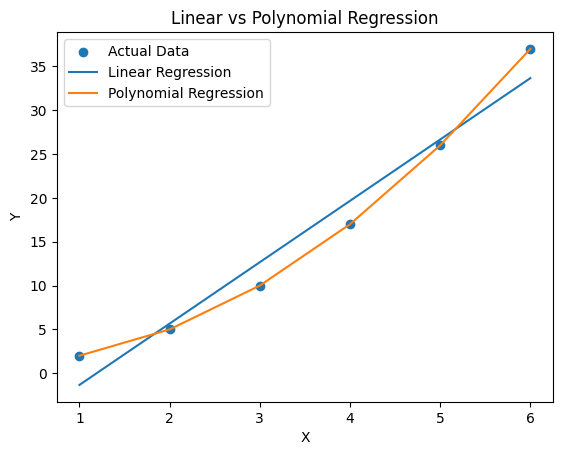

In [8]:
# 9. Compare Linear and Polynomial Regression

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Dataset
X = np.array([[1], [2], [3], [4], [5], [6]])
y = np.array([2, 5, 10, 17, 26, 37])

# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X, y)
linear_pred = linear_model.predict(X)

# Polynomial Regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)
poly_pred = poly_model.predict(X_poly)

# Display predictions
print("Linear Regression Predictions:")
print(linear_pred)

print("\nPolynomial Regression Predictions:")
print(poly_pred)

# Plot comparison
plt.scatter(X, y, label="Actual Data")
plt.plot(X, linear_pred, label="Linear Regression")
plt.plot(X, poly_pred, label="Polynomial Regression")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear vs Polynomial Regression")
plt.legend()
plt.show()

10. Expectation Maximization (EM) Algorithm

Cluster Means:
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]


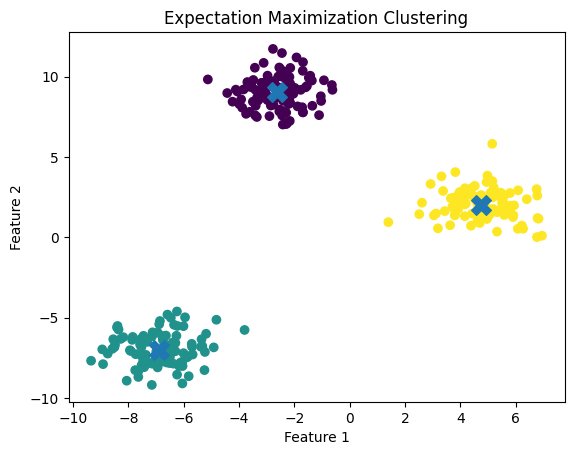

In [9]:
# 10. Expectation Maximization Algorithm

import numpy as np
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Create dataset
X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

# Create Gaussian Mixture Model
model = GaussianMixture(n_components=3, random_state=42)

# Train the model using EM Algorithm
model.fit(X)

# Predict clusters
labels = model.predict(X)

# Display cluster centers
print("Cluster Means:")
print(model.means_)

# Plot clusters
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(model.means_[:, 0], model.means_[:, 1], marker='X', s=200)

plt.title("Expectation Maximization Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

11. Credit Score Classification

In [10]:
# 11. Credit Score Classification

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Create dataset
data = {
    'Income': [25000, 30000, 45000, 50000, 60000, 70000, 80000, 90000, 35000, 55000],
    'Loan_Amount': [20000, 25000, 30000, 40000, 35000, 20000, 15000, 10000, 30000, 25000],
    'Credit_History': [1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    'Credit_Score': ['Poor', 'Poor', 'Standard', 'Standard', 'Good',
                     'Good', 'Good', 'Good', 'Poor', 'Standard']
}

df = pd.DataFrame(data)

# Input and output
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Encode output labels
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classify a new customer
new_customer = [[65000, 20000, 1]]

prediction = model.predict(new_customer)

print("Credit Score:", encoder.inverse_transform(prediction)[0])

Accuracy: 0.0
Credit Score: Good


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


12. Iris Flower Classification using KNN

In [11]:
# 12. Iris Flower Classification using KNN

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create KNN model
model = KNeighborsClassifier(n_neighbors=3)

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classify a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_flower)

print("Predicted Flower:", iris.target_names[prediction][0])

Accuracy: 1.0
Predicted Flower: setosa


13. Car Price Prediction Model

In [12]:
# 13. Car Price Prediction Model

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Create dataset
data = {
    'Year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Mileage': [80000, 70000, 65000, 55000, 50000, 40000, 30000, 20000, 15000, 5000],
    'Price': [400000, 450000, 500000, 550000, 600000, 700000, 800000, 900000, 1000000, 1200000]
}

df = pd.DataFrame(data)

# Input and output
X = df[['Year', 'Mileage']]
y = df['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display error
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Predict price of a new car
new_car = pd.DataFrame([[2022, 25000]], columns=['Year', 'Mileage'])

predicted_price = model.predict(new_car)

print("Predicted Car Price:", predicted_price[0])

Mean Squared Error: 128403302.87743762
Predicted Car Price: 873369.5652173907


14. House Price Prediction

In [13]:
# 14. House Price Prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Create dataset
data = {
    'Area': [1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000, 3500],
    'Bedrooms': [2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    'Price': [3000000, 3500000, 4500000, 5000000, 5500000,
              6000000, 7000000, 8000000, 8500000, 10000000]
}

df = pd.DataFrame(data)

# Input and output
X = df[['Area', 'Bedrooms']]
y = df['Price']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display error
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# Predict price of a new house
new_house = pd.DataFrame([[2400, 4]], columns=['Area', 'Bedrooms'])

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Mean Squared Error: 3690220886.2139673
Predicted House Price: 6769704.433497538


15. Iris Flower Classification using Naive Bayes

In [14]:
# 15. Iris Flower Classification using Naive Bayes

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Naive Bayes model
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classify a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_flower)

print("Predicted Flower:", iris.target_names[prediction][0])

Accuracy: 1.0
Predicted Flower: setosa


16. Compare Different Classification Algorithms

In [15]:
# 16. Compare Different Classification Algorithms

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Classification algorithms
models = {
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=200)
}

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(name, "Accuracy:", accuracy)

KNN Accuracy: 1.0
Naive Bayes Accuracy: 1.0
Decision Tree Accuracy: 1.0
Logistic Regression Accuracy: 1.0


17. Mobile Price Prediction

In [16]:
# 17. Mobile Price Prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Create dataset
data = {
    'RAM': [2, 3, 4, 4, 6, 8, 8, 12, 12, 16],
    'Storage': [32, 32, 64, 128, 128, 128, 256, 256, 512, 512],
    'Battery': [3000, 3500, 4000, 4500, 4500, 5000, 5000, 5500, 5000, 6000],
    'Price_Range': ['Low', 'Low', 'Low', 'Medium', 'Medium',
                    'Medium', 'High', 'High', 'High', 'High']
}

df = pd.DataFrame(data)

# Input and output
X = df[['RAM', 'Storage', 'Battery']]
y = df['Price_Range']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create and train model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Predict price range of a new mobile
new_mobile = [[8, 256, 5000]]
prediction = model.predict(new_mobile)

print("Predicted Price Range:", prediction[0])

Accuracy: 1.0
Predicted Price Range: High


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


18. Perceptron Based IRIS Classification

In [17]:
# 18. Perceptron Based IRIS Classification

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Perceptron model
model = Perceptron(max_iter=1000, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classify a new flower
new_flower = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(new_flower)

print("Predicted Flower:", iris.target_names[prediction][0])

Accuracy: 0.6333333333333333
Predicted Flower: setosa


19. Naive Bayes Classification for Bank Loan Prediction

In [18]:
# 19. Naive Bayes Classification for Bank Loan Prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Create dataset
data = {
    'Income': [25000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 35000, 55000],
    'Loan_Amount': [10000, 15000, 20000, 25000, 30000, 35000, 40000, 45000, 18000, 28000],
    'Credit_History': [0, 0, 1, 1, 1, 1, 1, 1, 0, 1],
    'Loan_Status': ['No', 'No', 'Yes', 'Yes', 'Yes',
                    'Yes', 'Yes', 'Yes', 'No', 'Yes']
}

df = pd.DataFrame(data)

# Input and output
X = df[['Income', 'Loan_Amount', 'Credit_History']]
y = df['Loan_Status']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Naive Bayes model
model = GaussianNB()

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Display accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Predict loan status for a new customer
new_customer = [[65000, 30000, 1]]
prediction = model.predict(new_customer)

print("Loan Status:", prediction[0])

Accuracy: 0.0
Loan Status: Yes


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


20. Future Sales Prediction

In [19]:
# 20. Future Sales Prediction

import pandas as pd
from sklearn.linear_model import LinearRegression

# Create dataset
data = {
    'Month': [1, 2, 3, 4, 5, 6, 7, 8],
    'Sales': [100, 120, 150, 170, 200, 220, 250, 280]
}

df = pd.DataFrame(data)

# Input and output
X = df[['Month']]
y = df['Sales']

# Create and train model
model = LinearRegression()
model.fit(X, y)

# Predict future sales
future_month = pd.DataFrame([[9]], columns=['Month'])
prediction = model.predict(future_month)

print("Predicted Sales for Month 9:", prediction[0])

Predicted Sales for Month 9: 301.42857142857144
